# Reverse Ratio simulation
The agents exchange a fixed amount of money and can incur debt up to a maximum limit.

We're trying to find out how to plot the revese ratio, the double sided M-G.

In [28]:
import importlib
import functions as func
import matplotlib.pyplot as plt
import numpy as np

func = importlib.reload(func)

In [29]:
N = 3500
M0 = 10000
r = 0.7
steps = 1e7

agents = func.simulate_double_sided(
    N=N,
    M0=M0,
    r=r,
    steps=steps,
    transaction_type="constant"
)

N_positive = N // 2
N_negative = N - N_positive
positive_agents = agents[:N_positive]
negative_agents = agents[N_positive:]

M_positive = M0 / r
M_negative = M0 * (1 - r) / r
T_plus = M_positive / N_positive
T_minus = M_negative / N_negative

print(f"Shape: {agents.shape}")
print(f"Positive money: {positive_agents.sum():.2f}")
print(f"Debt magnitude: {-negative_agents.sum():.2f}")
print(f"T+ = {T_plus:.2f}")
print(f"T- = {T_minus:.2f}")

Shape: (3500,)
Positive money: 14285.71
Debt magnitude: 4285.71
T+ = 8.16
T- = 2.45


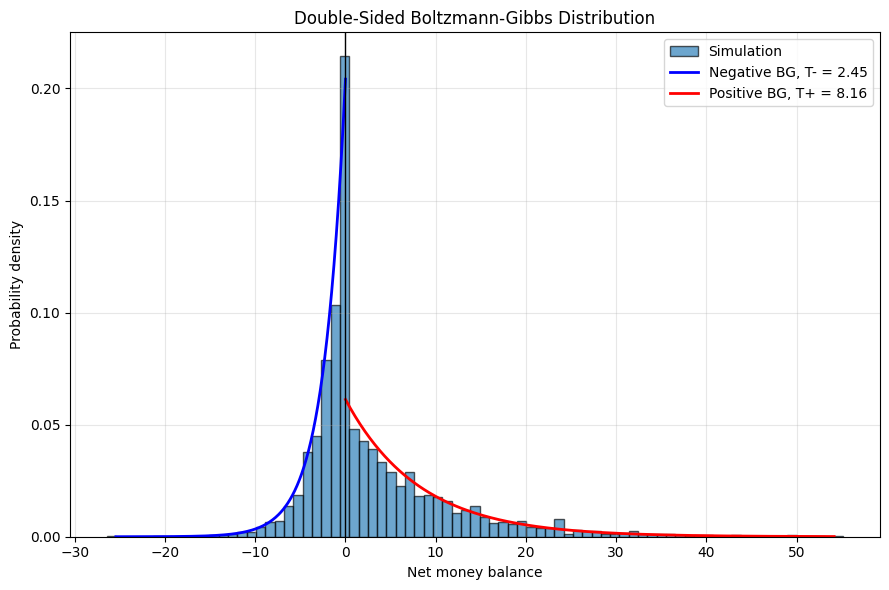

In [30]:
fig, ax = plt.subplots(figsize=(9, 6))

bins = np.linspace(agents.min() - 1, agents.max() + 1, 80)

ax.hist(
    agents,
    bins=bins,
    density=True,
    alpha=0.65,
    edgecolor="black",
    label="Simulation"
)

x_negative = np.linspace(agents.min(), 0, 300)
x_positive = np.linspace(0, agents.max(), 300)

p_negative = (
    (N_negative / N)
    * (1 / T_minus)
    * np.exp(x_negative / T_minus)
)
p_positive = (
    (N_positive / N)
    * (1 / T_plus)
    * np.exp(-x_positive / T_plus)
)

ax.plot(
    x_negative,
    p_negative,
    "b-",
    linewidth=2,
    label=f"Negative BG, T- = {T_minus:.2f}"
)
ax.plot(
    x_positive,
    p_positive,
    "r-",
    linewidth=2,
    label=f"Positive BG, T+ = {T_plus:.2f}"
)

ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Net money balance")
ax.set_ylabel("Probability density")
ax.set_title("Double-Sided Boltzmann-Gibbs Distribution")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()